Group members: Afaf Kabil, Anita Harkov, Ananya Chama, Clémence Biron, Sumeyye Pakdil

# 1. Project Overview & Objective

In [2]:
# Install required packages
!pip install pandas numpy matplotlib scipy statsmodels openpyxl

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import skew, kurtosis, norm

# Display settings
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")

print("Setup complete.")

Setup complete.


# 2. Data Selection & Preparation

In [4]:
from google.colab import files

# Map files manually
FILES = {
    "AMZN": Path("amazon.xlsx"),
    "AAPL": Path("apple.xlsx"),
    "JPM": Path("jpmorgan.xlsx"),
    "TGT": Path("target.xlsx"),
}

# Optional files
BENCHMARK_FILE = Path("benchmark.csv")
RF_FILE = Path("risk_free.csv")
FF_FILE = Path("fama_french_factors.csv")

# Output directory
DATA_DIR = Path(".")

data = {ticker: pd.read_excel(filepath) for ticker, filepath in FILES.items()}

# Show the first few rows of each file to confirm loading worked
for ticker, df in data.items():
    print(f"\n===== {ticker} =====")
    display(df.head())


===== AMZN =====


,Date,Price,CVol,Change,% Change,% Return,Total Return (Gross),Cumulative Return %,Open,High,Low,Cumulative Change %
0,2026-04-02,209.77,31453039.0,-0.80,-0.379921,-0.379921,209.77,32.723822,206.540,209.77,209.7700,32.723822
1,2026-04-01,210.57,45955400.0,2.30,1.104336,1.104336,210.57,33.229991,210.435,213.58,208.1900,33.229991
2,2026-03-31,208.27,58470080.0,7.32,3.642697,3.642697,208.27,31.774755,204.845,210.28,204.1400,31.774755
3,2026-03-30,200.95,46373800.0,1.61,0.807665,0.807665,200.95,27.143309,201.480,203.80,199.9802,27.143309
4,2026-03-27,199.34,56009760.0,-8.20,-3.951046,-3.951046,199.34,26.124644,206.455,206.60,199.1400,26.124644



===== AAPL =====


,Date,Price,CVol,Change,% Change,% Return,Total Return (Gross),Cumulative Return %,Open,High,Low,Cumulative Change %
0,2026-04-02,255.92,31248880.0,0.29,0.113445,0.113440,262.72675,113.598984,254.20,256.130,250.650,108.065041
1,2026-04-01,255.63,40059434.0,1.84,0.725009,0.725013,262.42905,113.356951,254.08,256.180,253.330,107.829268
2,2026-03-31,253.79,49598090.0,7.16,2.903134,2.903132,260.54010,111.821220,247.91,255.480,247.101,106.333333
3,2026-03-30,246.63,39446207.0,-2.17,-0.872186,-0.872188,253.18967,105.845260,250.07,250.870,245.510,100.512195
4,2026-03-27,248.80,47900000.0,-4.09,-1.617304,-1.617307,255.41739,107.656415,253.90,255.493,248.070,102.276423



===== JPM =====


,Date,Price,CVol,Change,% Change,% Return,Total Return (Gross),Cumulative Return %,Open,High,Low,Cumulative Change %
0,2026-04-02,294.60,6668148.0,-0.78,-0.264067,-0.264068,334.69833,117.746620,291.91,294.600,294.600,91.659619
1,2026-04-01,295.38,11267170.0,1.22,0.414740,0.414736,335.58450,118.323141,295.39,298.720,292.910,92.167068
2,2026-03-31,294.16,12956880.0,10.39,3.661416,3.661427,334.19846,117.421417,288.47,295.072,284.945,91.373365
3,2026-03-30,283.77,11734350.0,0.93,0.328808,0.328807,322.39423,109.741871,284.74,287.250,282.330,84.613883
4,2026-03-27,282.84,9873292.0,-8.82,-3.024069,-3.024069,321.33765,109.054486,289.14,290.110,281.750,84.008848



===== TGT =====


,Date,Price,CVol,Change,% Change,% Return,Total Return (Gross),Cumulative Return %,Open,High,Low,Cumulative Change %
0,2026-04-02,120.45,5347625.0,0.00,0.000000,NaN,139.42218,-30.538970,120.30,120.450,120.45,-39.991032
1,2026-04-01,120.45,4250948.0,-0.75,-0.618812,-0.618810,139.42218,-30.538970,121.15,122.145,120.41,-39.991032
2,2026-03-31,121.20,4662081.0,2.42,2.037380,2.037368,140.29031,-30.106462,119.90,121.340,118.78,-39.617377
3,2026-03-30,118.78,4425179.0,-1.06,-0.884513,-0.884512,137.48915,-31.502018,120.12,121.500,117.94,-40.823037
4,2026-03-27,119.84,8112912.0,2.84,2.427350,2.427357,138.71611,-30.890738,117.10,121.460,116.50,-40.294938


In [6]:
def load_factset_price_history(file_path: Path, ticker: str) -> pd.DataFrame:
    df = pd.read_excel(file_path, sheet_name="Price History", header=2)

    df = df.rename(columns={df.columns[0]: "Date", df.columns[1]: "Price"})
    df = df[["Date", "Price"]].copy()

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

    df = df.dropna(subset=["Date", "Price"])
    df = df.sort_values("Date").reset_index(drop=True)

    df[ticker + "_Return"] = df["Price"].pct_change()
    df = df.rename(columns={"Price": ticker + "_Price"})

    return df

# Load assets
asset_data = {}
for ticker, path in FILES.items():
    asset_data[ticker] = load_factset_price_history(path, ticker)



# 3. Time-Series & Volatility Analysis

In [7]:
# Merge datasets
prices, returns = None, None

for ticker, df in asset_data.items():
    price_col = ["Date", f"{ticker}_Price"]
    return_col = ["Date", f"{ticker}_Return"]

    if prices is None:
        prices = df[price_col].copy()
        returns = df[return_col].copy()
    else:
        prices = prices.merge(df[price_col], on="Date", how="inner")
        returns = returns.merge(df[return_col], on="Date", how="inner")

returns = returns.dropna().set_index("Date")
prices = prices.set_index("Date").loc[returns.index]

print("Data loaded successfully")
print("Returns shape:", returns.shape)
returns.head()

Data loaded successfully
Returns shape: (1254, 4)


,AMZN_Return,AAPL_Return,JPM_Return,TGT_Return
Date,,,,
2021-04-05,0.020794,0.023577,-0.000586,0.023067
2021-04-06,-0.000902,0.002462,-0.007030,0.000390
2021-04-07,0.017237,0.013390,0.015668,-0.004770
2021-04-08,0.006071,0.019234,0.001226,-0.004842
2021-04-09,0.022096,0.020213,0.007478,0.009338


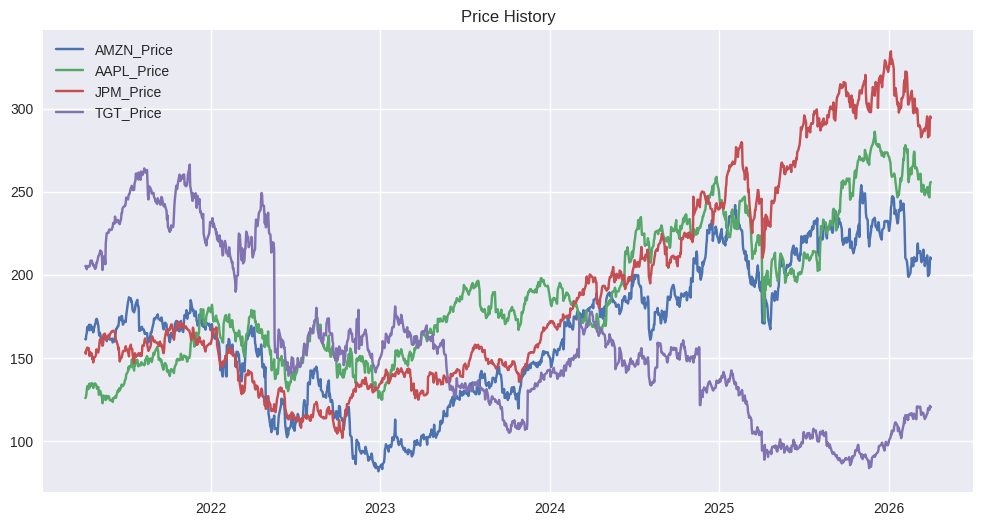

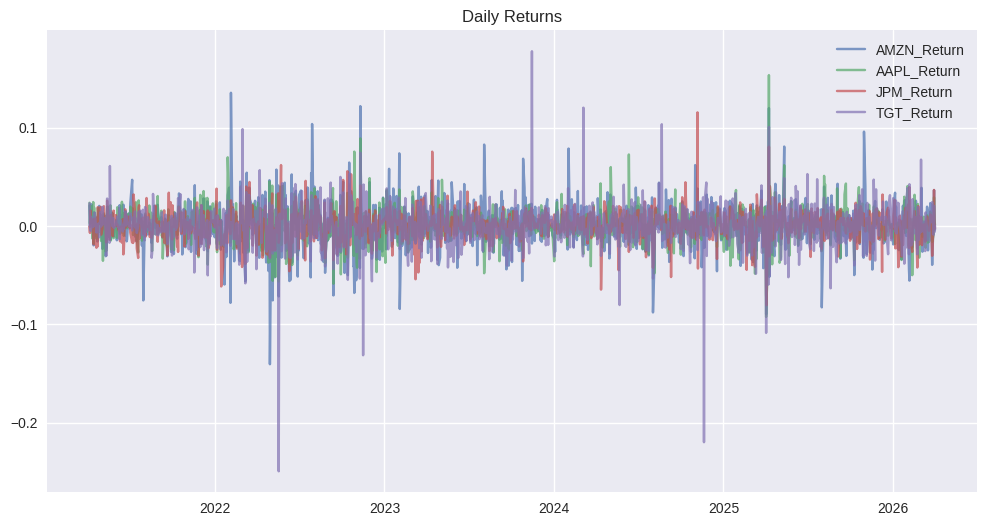

                 Mean   Std Dev      Skew   Kurtosis  Annual Return  \
AMZN_Return  0.000472  0.022237  0.129480   5.031284       0.119028   
AAPL_Return  0.000732  0.017289  0.459742   6.956906       0.184502   
JPM_Return   0.000636  0.015373  0.085022   5.171578       0.160294   
TGT_Return  -0.000154  0.022172 -1.423159  25.589950      -0.038740   

             Annual Vol  
AMZN_Return    0.353001  
AAPL_Return    0.274454  
JPM_Return     0.244040  
TGT_Return     0.351972  


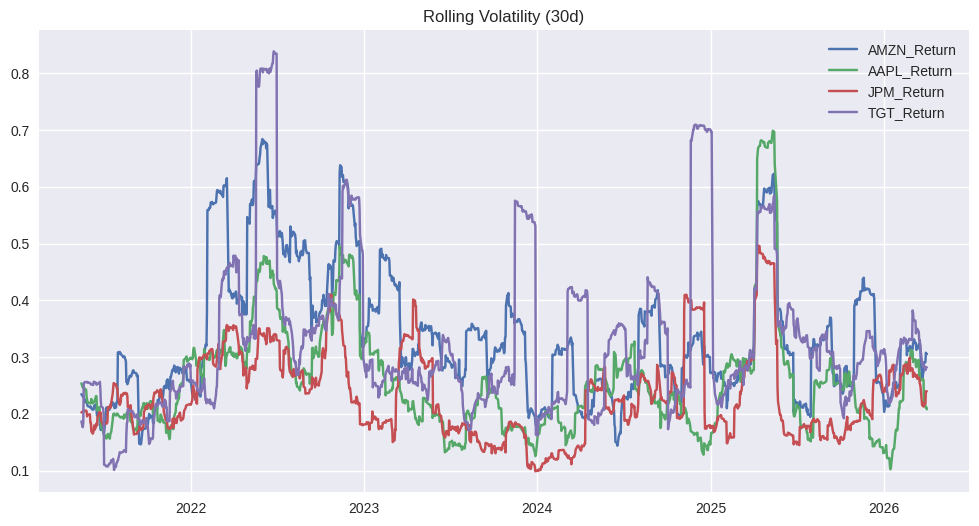

In [ ]:
# Price plot
plt.figure(figsize=(12,6))
for col in prices.columns:
    plt.plot(prices.index, prices[col], label=col)
plt.title("Price History")
plt.legend()
plt.show()

# Returns plot
plt.figure(figsize=(12,6))
for col in returns.columns:
    plt.plot(returns.index, returns[col], label=col, alpha=0.7)
plt.title("Daily Returns")
plt.legend()
plt.show()

# Summary stats
summary_stats = pd.DataFrame({
    "Mean": returns.mean(),
    "Std Dev": returns.std(),
    "Skew": returns.apply(skew),
    "Kurtosis": returns.apply(kurtosis),
    "Annual Return": returns.mean() * 252,
    "Annual Vol": returns.std() * np.sqrt(252),
})

print(summary_stats)

# Rolling volatility
rolling_vol = returns.rolling(30).std() * np.sqrt(252)

plt.figure(figsize=(12,6))
for col in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[col], label=col)
plt.title("Rolling Volatility (30d)")
plt.legend()
plt.show()

# 4. Portfolio Construction & Risk

In [ ]:
n_assets = returns.shape[1]

# Equal weights
ew_weights = np.repeat(1/n_assets, n_assets)

# Min variance
cov_matrix = returns.cov() * 252
mean_returns = returns.mean() * 252

def portfolio_volatility(weights):
    return np.sqrt(weights.T @ cov_matrix @ weights)

def constraint(weights):
    return np.sum(weights) - 1

bounds = tuple((0,1) for _ in range(n_assets))
init = np.repeat(1/n_assets, n_assets)

result = minimize(portfolio_volatility, init,
                  method='SLSQP',
                  bounds=bounds,
                  constraints={'type':'eq','fun':constraint})

minvar_weights = result.x

weights = pd.DataFrame({
    "Asset": returns.columns,
    "Equal": ew_weights,
    "MinVar": minvar_weights
})

print(weights)

         Asset  Equal    MinVar
0  AMZN_Return   0.25  0.036818
1  AAPL_Return   0.25  0.316237
2   JPM_Return   0.25  0.506615
3   TGT_Return   0.25  0.140329


In [ ]:
portfolio_returns = pd.DataFrame(index=returns.index)

portfolio_returns["Equal"] = returns @ ew_weights
portfolio_returns["MinVar"] = returns @ minvar_weights

metrics = pd.DataFrame(index=["Equal","MinVar"])

metrics["Return"] = portfolio_returns.mean()*252
metrics["Volatility"] = portfolio_returns.std()*np.sqrt(252)
metrics["Sharpe"] = metrics["Return"] / metrics["Volatility"]

print(metrics)

          Return  Volatility    Sharpe
Equal   0.106271    0.224840  0.472652
MinVar  0.138500    0.207913  0.666143


             AMZN_Return  AAPL_Return  JPM_Return  TGT_Return
AMZN_Return     1.000000     0.546856    0.363168    0.343131
AAPL_Return     0.546856     1.000000    0.379028    0.342948
JPM_Return      0.363168     0.379028    1.000000    0.318074
TGT_Return      0.343131     0.342948    0.318074    1.000000


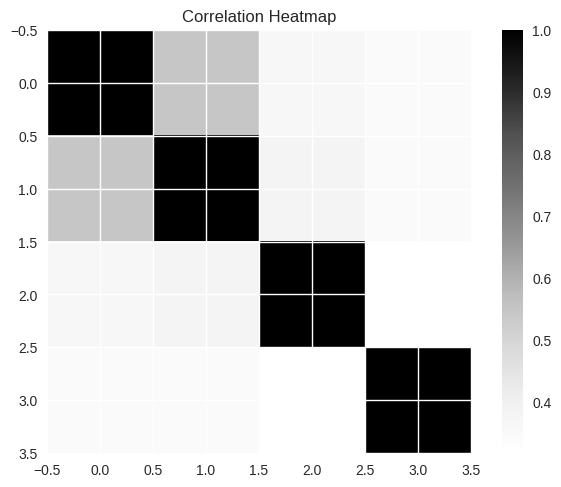

        Weighted Asset Vol  Portfolio Vol   Benefit
Equal             0.305867       0.224840  0.081027
MinVar            0.272816       0.207913  0.064903


In [ ]:
# Correlation
corr = returns.corr()
print(corr)

plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

# Diversification
avg_vol = returns.std()*np.sqrt(252)

div = pd.DataFrame({
    "Weighted Asset Vol": [
        np.dot(ew_weights, avg_vol),
        np.dot(minvar_weights, avg_vol)
    ],
    "Portfolio Vol": [
        metrics.loc["Equal","Volatility"],
        metrics.loc["MinVar","Volatility"]
    ]
}, index=["Equal","MinVar"])

div["Benefit"] = div["Weighted Asset Vol"] - div["Portfolio Vol"]
print(div)

             VaR      CVaR
Equal  -0.022912 -0.033654
MinVar -0.021233 -0.030185


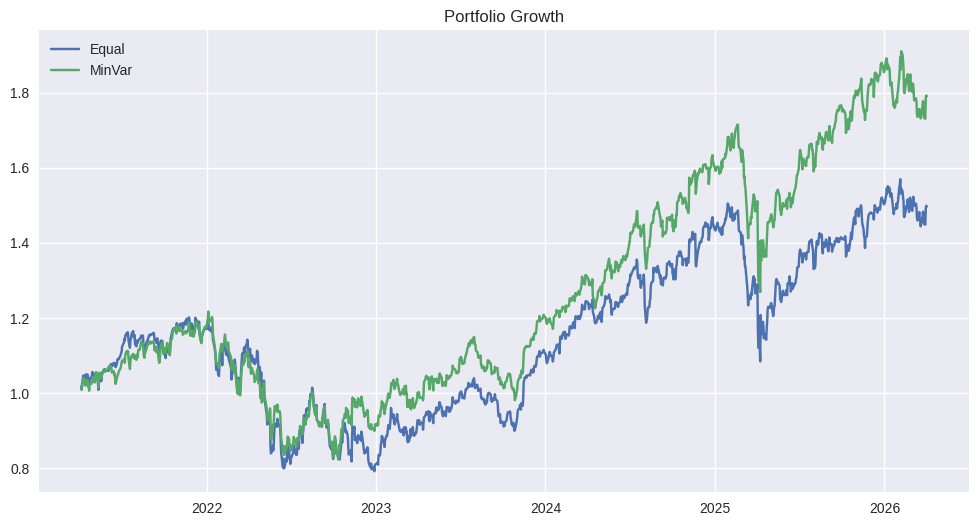

In [ ]:
def var(x): return np.quantile(x, 0.05)
def cvar(x): return x[x <= var(x)].mean()

risk = pd.DataFrame(index=portfolio_returns.columns)
risk["VaR"] = portfolio_returns.apply(var)
risk["CVaR"] = portfolio_returns.apply(cvar)

print(risk)

# Growth plot
growth = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12,6))
for col in growth.columns:
    plt.plot(growth.index, growth[col], label=col)
plt.legend()
plt.title("Portfolio Growth")
plt.show()

# 5. Asset Pricing Models

In [ ]:
import statsmodels.api as sm

if FF_FILE.exists():
    ff = pd.read_csv(FF_FILE)
    ff["Date"] = pd.to_datetime(ff["Date"])
    ff = ff.set_index("Date")

    df = portfolio_returns.join(ff, how="inner")

    factors = ["MKT_RF","SMB","HML","RMW","CMA"]

    for p in portfolio_returns.columns:
        y = df[p] - df["RF"]
        X = sm.add_constant(df[factors])
        model = sm.OLS(y, X).fit()
        print(model.summary())

In [ ]:
summary_stats.to_csv("summary_stats.csv")
metrics.to_csv("portfolio_metrics.csv")
risk.to_csv("risk_metrics.csv")
corr.to_csv("correlation.csv")
weights.to_csv("weights.csv", index=False)

print("Files exported successfully.")

Files exported successfully.


5

In [ ]:
# ============================================
# SECTION 5 / FACTOR MODEL EXTENSION

# -------------------------------------------------
# 0. DEFINE FACTOR FILES TO MATCH YOUR NOTEBOOK
# -------------------------------------------------

FF3_FILE = Path("ff3.xlsx")
FF5_FILE = Path("ff5.xlsx")


# -------------------------------------------------
# 1. BUILD PORTFOLIO RETURNS FROM EXISTING 'returns'
# -------------------------------------------------

returns_matrix = returns.copy()
asset_cols = returns_matrix.columns.tolist()

# Equal-weighted portfolio
n_assets = len(asset_cols)
ew_weights = np.repeat(1 / n_assets, n_assets)
returns_matrix["Equal_Weighted"] = returns_matrix[asset_cols].dot(ew_weights)

# Minimum-variance portfolio
cov_daily = returns_matrix[asset_cols].cov()

def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)

def sum_weights(weights):
    return np.sum(weights) - 1

bounds = tuple((0, 1) for _ in range(n_assets))
constraints = ({"type": "eq", "fun": sum_weights},)
initial_guess = np.repeat(1 / n_assets, n_assets)

result = minimize(
    portfolio_volatility,
    initial_guess,
    args=(cov_daily,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

minvar_weights = result.x
returns_matrix["Min_Variance"] = returns_matrix[asset_cols].dot(minvar_weights)

print("\n=== PORTFOLIO WEIGHTS ===")
weights_df = pd.DataFrame({
    "Asset": asset_cols,
    "Equal_Weight": ew_weights,
    "Min_Variance_Weight": minvar_weights
})
print(weights_df)


# -------------------------------------------------
# 2. LOAD FAMA-FRENCH 3-FACTOR DATA
# -------------------------------------------------

def load_ff3(file_path):
    ff3 = pd.read_excel(file_path, sheet_name="Sheet1", header=0)
    ff3.columns = ["Date", "MKT_RF", "SMB", "HML", "RF"]
    ff3 = ff3.dropna(subset=["Date"])
    ff3["Date"] = pd.to_numeric(ff3["Date"], errors="coerce")
    ff3 = ff3.dropna(subset=["Date"])
    ff3["Date"] = pd.to_datetime(ff3["Date"].astype(int).astype(str), format="%Y%m%d", errors="coerce")
    ff3 = ff3.dropna(subset=["Date"])

    for col in ["MKT_RF", "SMB", "HML", "RF"]:
        ff3[col] = pd.to_numeric(ff3[col], errors="coerce") / 100.0

    ff3 = ff3.dropna().sort_values("Date").reset_index(drop=True)
    return ff3

ff3 = load_ff3(FF3_FILE)
print("\n=== FF3 FACTORS ===")
print(ff3.head())


# -------------------------------------------------
# 3. MERGE STOCKS/PORTFOLIOS WITH FF3
# -------------------------------------------------

all_returns = returns_matrix.reset_index()
merged = all_returns.merge(ff3, on="Date", how="inner")

analysis_assets = asset_cols + ["Equal_Weighted", "Min_Variance"]

print("\n=== MERGED DATA ===")
print(merged[["Date"] + analysis_assets + ["MKT_RF", "SMB", "HML", "RF"]].head())


# -------------------------------------------------
# 4. RUN CAPM AND FF3 REGRESSIONS
# -------------------------------------------------

def run_factor_model(df, asset_col, factor_cols):
    reg_df = df[[asset_col, "RF"] + factor_cols].dropna().copy()
    reg_df["Excess_Return"] = reg_df[asset_col] - reg_df["RF"]

    X = sm.add_constant(reg_df[factor_cols])
    y = reg_df["Excess_Return"]

    model = sm.OLS(y, X).fit()
    return model

capm_results = {}
ff3_results = {}

for asset in analysis_assets:
    capm_results[asset] = run_factor_model(merged, asset, ["MKT_RF"])
    ff3_results[asset] = run_factor_model(merged, asset, ["MKT_RF", "SMB", "HML"])


# -------------------------------------------------
# 5. EXTRACT RESULTS INTO TABLES
# -------------------------------------------------

def summarize_model(model, model_name, asset_name):
    summary = {
        "Asset": asset_name,
        "Model": model_name,
        "Alpha": model.params.get("const", np.nan),
        "Alpha_pvalue": model.pvalues.get("const", np.nan),
        "R_squared": model.rsquared,
        "Adj_R_squared": model.rsquared_adj,
        "Obs": int(model.nobs)
    }

    for var in model.params.index:
        if var != "const":
            summary[f"Beta_{var}"] = model.params[var]
            summary[f"Pvalue_{var}"] = model.pvalues[var]

    return summary

capm_table = pd.DataFrame([
    summarize_model(capm_results[a], "CAPM", a) for a in analysis_assets
])

ff3_table = pd.DataFrame([
    summarize_model(ff3_results[a], "FF3", a) for a in analysis_assets
])

print("\n=== CAPM RESULTS ===")
print(capm_table)

print("\n=== FF3 RESULTS ===")
print(ff3_table)


# -------------------------------------------------
# 6. COMPARE CAPM VS FF3
# -------------------------------------------------

comparison = capm_table[["Asset", "Alpha", "Alpha_pvalue", "R_squared", "Adj_R_squared"]].merge(
    ff3_table[["Asset", "Alpha", "Alpha_pvalue", "R_squared", "Adj_R_squared"]],
    on="Asset",
    suffixes=("_CAPM", "_FF3")
)

comparison["Delta_R2"] = comparison["R_squared_FF3"] - comparison["R_squared_CAPM"]
comparison["Alpha_Change"] = comparison["Alpha_FF3"] - comparison["Alpha_CAPM"]

print("\n=== MODEL COMPARISON ===")
print(comparison)


# -------------------------------------------------
# 7. ECONOMIC INTERPRETATION
# -------------------------------------------------

def interpret_ff3_row(row):
    asset = row["Asset"]
    alpha = row.get("Alpha", np.nan)
    alpha_p = row.get("Alpha_pvalue", np.nan)
    beta_mkt = row.get("Beta_MKT_RF", np.nan)
    beta_smb = row.get("Beta_SMB", np.nan)
    beta_hml = row.get("Beta_HML", np.nan)
    r2 = row.get("R_squared", np.nan)

    comments = []

    if pd.notna(beta_mkt):
        if beta_mkt > 1.05:
            comments.append("high market sensitivity")
        elif beta_mkt < 0.95:
            comments.append("below-market sensitivity")
        else:
            comments.append("market-like sensitivity")

    if pd.notna(beta_smb):
        if beta_smb > 0.05:
            comments.append("tilts toward smaller-cap behavior")
        elif beta_smb < -0.05:
            comments.append("tilts toward large-cap behavior")

    if pd.notna(beta_hml):
        if beta_hml > 0.05:
            comments.append("shows value exposure")
        elif beta_hml < -0.05:
            comments.append("shows growth exposure")

    if pd.notna(alpha) and pd.notna(alpha_p):
        if alpha_p < 0.05 and alpha > 0:
            comments.append("positive statistically significant alpha persists after controlling for factor risk")
        elif alpha_p < 0.05 and alpha < 0:
            comments.append("negative statistically significant alpha after controlling for factor risk")
        else:
            comments.append("no statistically significant alpha after controlling for factor risk")

    comments.append(f"model explains {r2:.2%} of excess return variation")
    return f"{asset}: " + "; ".join(comments) + "."

print("\n=== ECONOMIC INTERPRETATIONS (FF3) ===")
for _, row in ff3_table.iterrows():
    print(interpret_ff3_row(row))


# -------------------------------------------------
# 8. LOAD FAMA-FRENCH 5-FACTOR DATA
# -------------------------------------------------

def load_ff5(file_path):
    ff5 = pd.read_excel(file_path, sheet_name="Sheet1", header=0)
    ff5.columns = ["Date", "MKT_RF", "SMB", "HML", "RMW", "CMA", "RF"]
    ff5 = ff5.dropna(subset=["Date"])
    ff5["Date"] = pd.to_numeric(ff5["Date"], errors="coerce")
    ff5 = ff5.dropna(subset=["Date"])
    ff5["Date"] = pd.to_datetime(ff5["Date"].astype(int).astype(str), format="%Y%m%d", errors="coerce")
    ff5 = ff5.dropna(subset=["Date"])

    for col in ["MKT_RF", "SMB", "HML", "RMW", "CMA", "RF"]:
        ff5[col] = pd.to_numeric(ff5[col], errors="coerce") / 100.0

    ff5 = ff5.dropna().sort_values("Date").reset_index(drop=True)
    return ff5

ff5 = load_ff5(FF5_FILE)
merged_ff5 = all_returns.merge(ff5, on="Date", how="inner")

ff5_results = {}
for asset in analysis_assets:
    ff5_results[asset] = run_factor_model(merged_ff5, asset, ["MKT_RF", "SMB", "HML", "RMW", "CMA"])

ff5_table = pd.DataFrame([
    summarize_model(ff5_results[a], "FF5", a) for a in analysis_assets
])

print("\n=== FF5 RESULTS ===")
print(ff5_table)


# -------------------------------------------------
# 9. COMPARE FF3 VS FF5
# -------------------------------------------------

ff3_vs_ff5 = ff3_table[["Asset", "Alpha", "R_squared", "Adj_R_squared"]].merge(
    ff5_table[["Asset", "Alpha", "R_squared", "Adj_R_squared"]],
    on="Asset",
    suffixes=("_FF3", "_FF5")
)

ff3_vs_ff5["Delta_R2_FF5_minus_FF3"] = ff3_vs_ff5["R_squared_FF5"] - ff3_vs_ff5["R_squared_FF3"]
ff3_vs_ff5["Alpha_Change_FF5_minus_FF3"] = ff3_vs_ff5["Alpha_FF5"] - ff3_vs_ff5["Alpha_FF3"]

print("\n=== FF3 VS FF5 COMPARISON ===")
print(ff3_vs_ff5)


# -------------------------------------------------
# 10. SAVE OUTPUTS USING NOTEBOOK VARIABLE DATADIR
# -------------------------------------------------
from pathlib import Path
DATADIR = Path(".")

capm_table.to_csv(DATADIR / "capm_results.csv", index=False)
ff3_table.to_csv(DATADIR / "ff3_results.csv", index=False)
ff5_table.to_csv(DATADIR / "ff5_results.csv", index=False)

comparison.to_csv(DATADIR / "capm_vs_ff3_comparison.csv", index=False)
ff3_vs_ff5.to_csv(DATADIR / "ff3_vs_ff5_comparison.csv", index=False)
weights_df.to_csv(DATADIR / "section5_portfolio_weights.csv", index=False)

print("\nSaved files:")
print("- capm_results.csv")
print("- ff3_results.csv")
print("- ff5_results.csv")
print("- capm_vs_ff3_comparison.csv")
print("- ff3_vs_ff5_comparison.csv")
print("- section5_portfolio_weights.csv")


=== PORTFOLIO WEIGHTS ===
         Asset  Equal_Weight  Min_Variance_Weight
0  AMZN_Return          0.25             0.035581
1  AAPL_Return          0.25             0.316931
2   JPM_Return          0.25             0.505474
3   TGT_Return          0.25             0.142015

=== FF3 FACTORS ===
        Date  MKT_RF     SMB     HML   RF
0 2022-01-03  0.0072  0.0035  0.0077  0.0
1 2022-01-04 -0.0027 -0.0081  0.0364  0.0
2 2022-01-05 -0.0226 -0.0146  0.0258  0.0
3 2022-01-06  0.0000  0.0021  0.0176  0.0
4 2022-01-07 -0.0049 -0.0132  0.0202  0.0

=== MERGED DATA ===
        Date  AMZN_Return  AAPL_Return  JPM_Return  TGT_Return  \
0 2022-01-03     0.022118     0.025004    0.021156    0.002204   
1 2022-01-04    -0.016916    -0.012692    0.037910    0.009571   
2 2022-01-05    -0.018893    -0.026600   -0.024132   -0.022676   
3 2022-01-06    -0.006711    -0.016693    0.010624    0.010880   
4 2022-01-07    -0.004288     0.000988    0.009908   -0.002464   

   Equal_Weighted  Min_Variance 

# 6. AI use
1) **AI Tool Used:**
ChatGPT (OpenAI), Claude and Gemini
2) **Purpose:**
To assist with summarizing 10-K filings, interpreting sentiment analysis results, refining presentation content, and clarifying and editing Python code used in the Living Book.
3) **Portions Affected:**
Sections involving text summaries, sentiment analysis discussion, speaker notes, wording of conclusions and recommendations, and explanations or revisions of Python code included in the Living Book.
4) **Prompts Used:**
Prompts focused on summarizing financial disclosures, rewriting content for clarity, summarizing speaker notes, condensing insights into concise statements, and clarifying, troubleshooting, or editing Python code.
“Target Corporation: 10-K Files” FactSet, FactSet Research Systems Inc., https://my.apps.factset.com/workstation/navigator/company-security/filings/TGT-US, accessed on April 15, 2025.